In [1]:
import timm
import torch
import numpy as np
import urllib
from PIL import Image
from torchvision import transforms
import sys
from pathlib import Path
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

PROJECT_ROOT = Path().resolve().parent
sys.path.insert(0, str(PROJECT_ROOT))


In [2]:
from tokenfool.attacks.patchfool import PatchFool
from tokenfool.adapters.vision_transformer import VisionTransformerClassifier

Fetch imagenet class labels

In [3]:
url = "https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
imagenet_classes = urllib.request.urlopen(url).read().decode("utf-8").split("\n")

Initialize DeiT model

In [4]:
deit = timm.create_model(
    "deit_tiny_patch16_224",
    pretrained=True
).to(device).eval()


Initial image and prediction

Predicted class: 7 (cock)


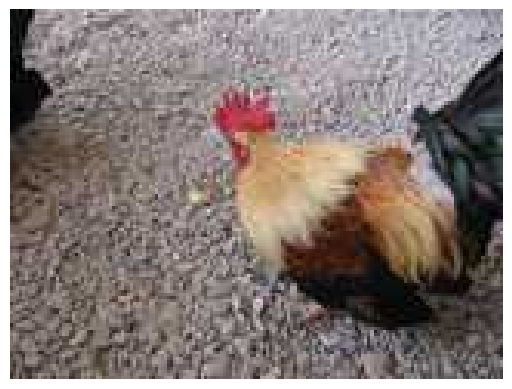

In [5]:
image_path = Path("test_data/ILSVRC2012_val_00003606.JPEG")
raw_image = Image.open(image_path).convert("RGB")
plt.imshow(raw_image)
plt.axis("off")

preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

img = preprocess(raw_image).unsqueeze(0).to(device)

pred = deit(img)
pred_class = pred.argmax(dim=1).item()

print(f"Predicted class: {pred_class} ({imagenet_classes[pred_class]})")

Attack - default parameters

In [9]:
# wrap model in adapter
tokenfool_model = VisionTransformerClassifier(deit)

x_adv, mask = PatchFool(model=tokenfool_model, x=img, progress=True)

PatchFool:   0%|          | 0/250 [00:00<?, ?it/s]

Attacked image and prediction

Adversarial class: 75 (black widow)


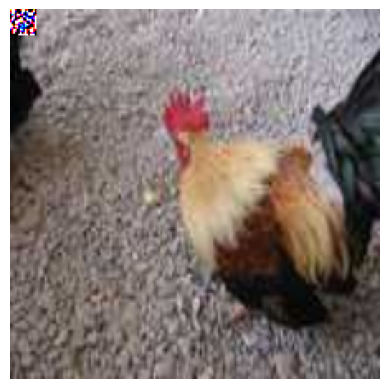

In [10]:
img_adv = x_adv[0].detach().cpu()
img_adv = img_adv * torch.tensor([0.229,0.224,0.225]).view(3,1,1)
img_adv = img_adv + torch.tensor([0.485,0.456,0.406]).view(3,1,1)
plt.imshow(img_adv.permute(1,2,0).clamp(0,1))
plt.axis("off")

pred_adv = deit(x_adv)
pred_adv_class = pred_adv.argmax(dim=1).item()

print(f"Adversarial class: {pred_adv_class} ({imagenet_classes[pred_adv_class]})")

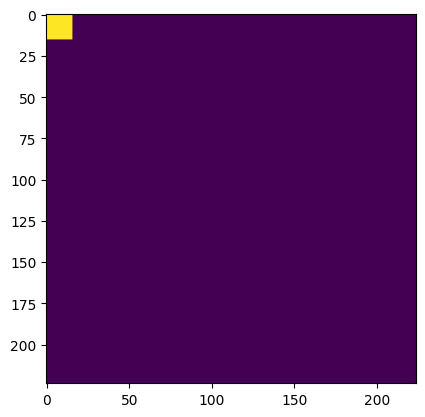

In [11]:
mask = mask[0].detach().cpu()
mask = mask.permute(1,2,0)
plt.imshow(mask)